# Notebook 02 - Occupancy Proxy

This notebook focuses on deriving the **Occupancy Proxies** for MCO and Thingy sesnsors based on time-based analysis on loudness and sound accordingly. 

## Part 0 - Setup

In [215]:
!pip install sparqlwrapper pandas

In [5]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

ENDPOINT = "http://136.113.132.176:7001"


def execute_query(query):
    sparql = SPARQLWrapper(ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.setMethod("POST")
    sparql.setTimeout(180)
    
    results = sparql.query().convert()
    vars_ = results["head"]["vars"]
    bindings = results["results"]["bindings"]
    
    data = []
    for row in bindings:
        entry = {}
        for var in vars_:
            entry[var] = row[var]["value"] if var in row else None
        data.append(entry)
    
    return pd.DataFrame(data)

try:
    test = execute_query("SELECT * WHERE {} LIMIT 1")
    print("Connection to QLever established:", ENDPOINT)
except:
    print("Connection to QLever failed.")
    

Connection to QLever established: http://136.113.132.176:7001


## Part 1 - MCO Proxy

### Loudness over year per sensor

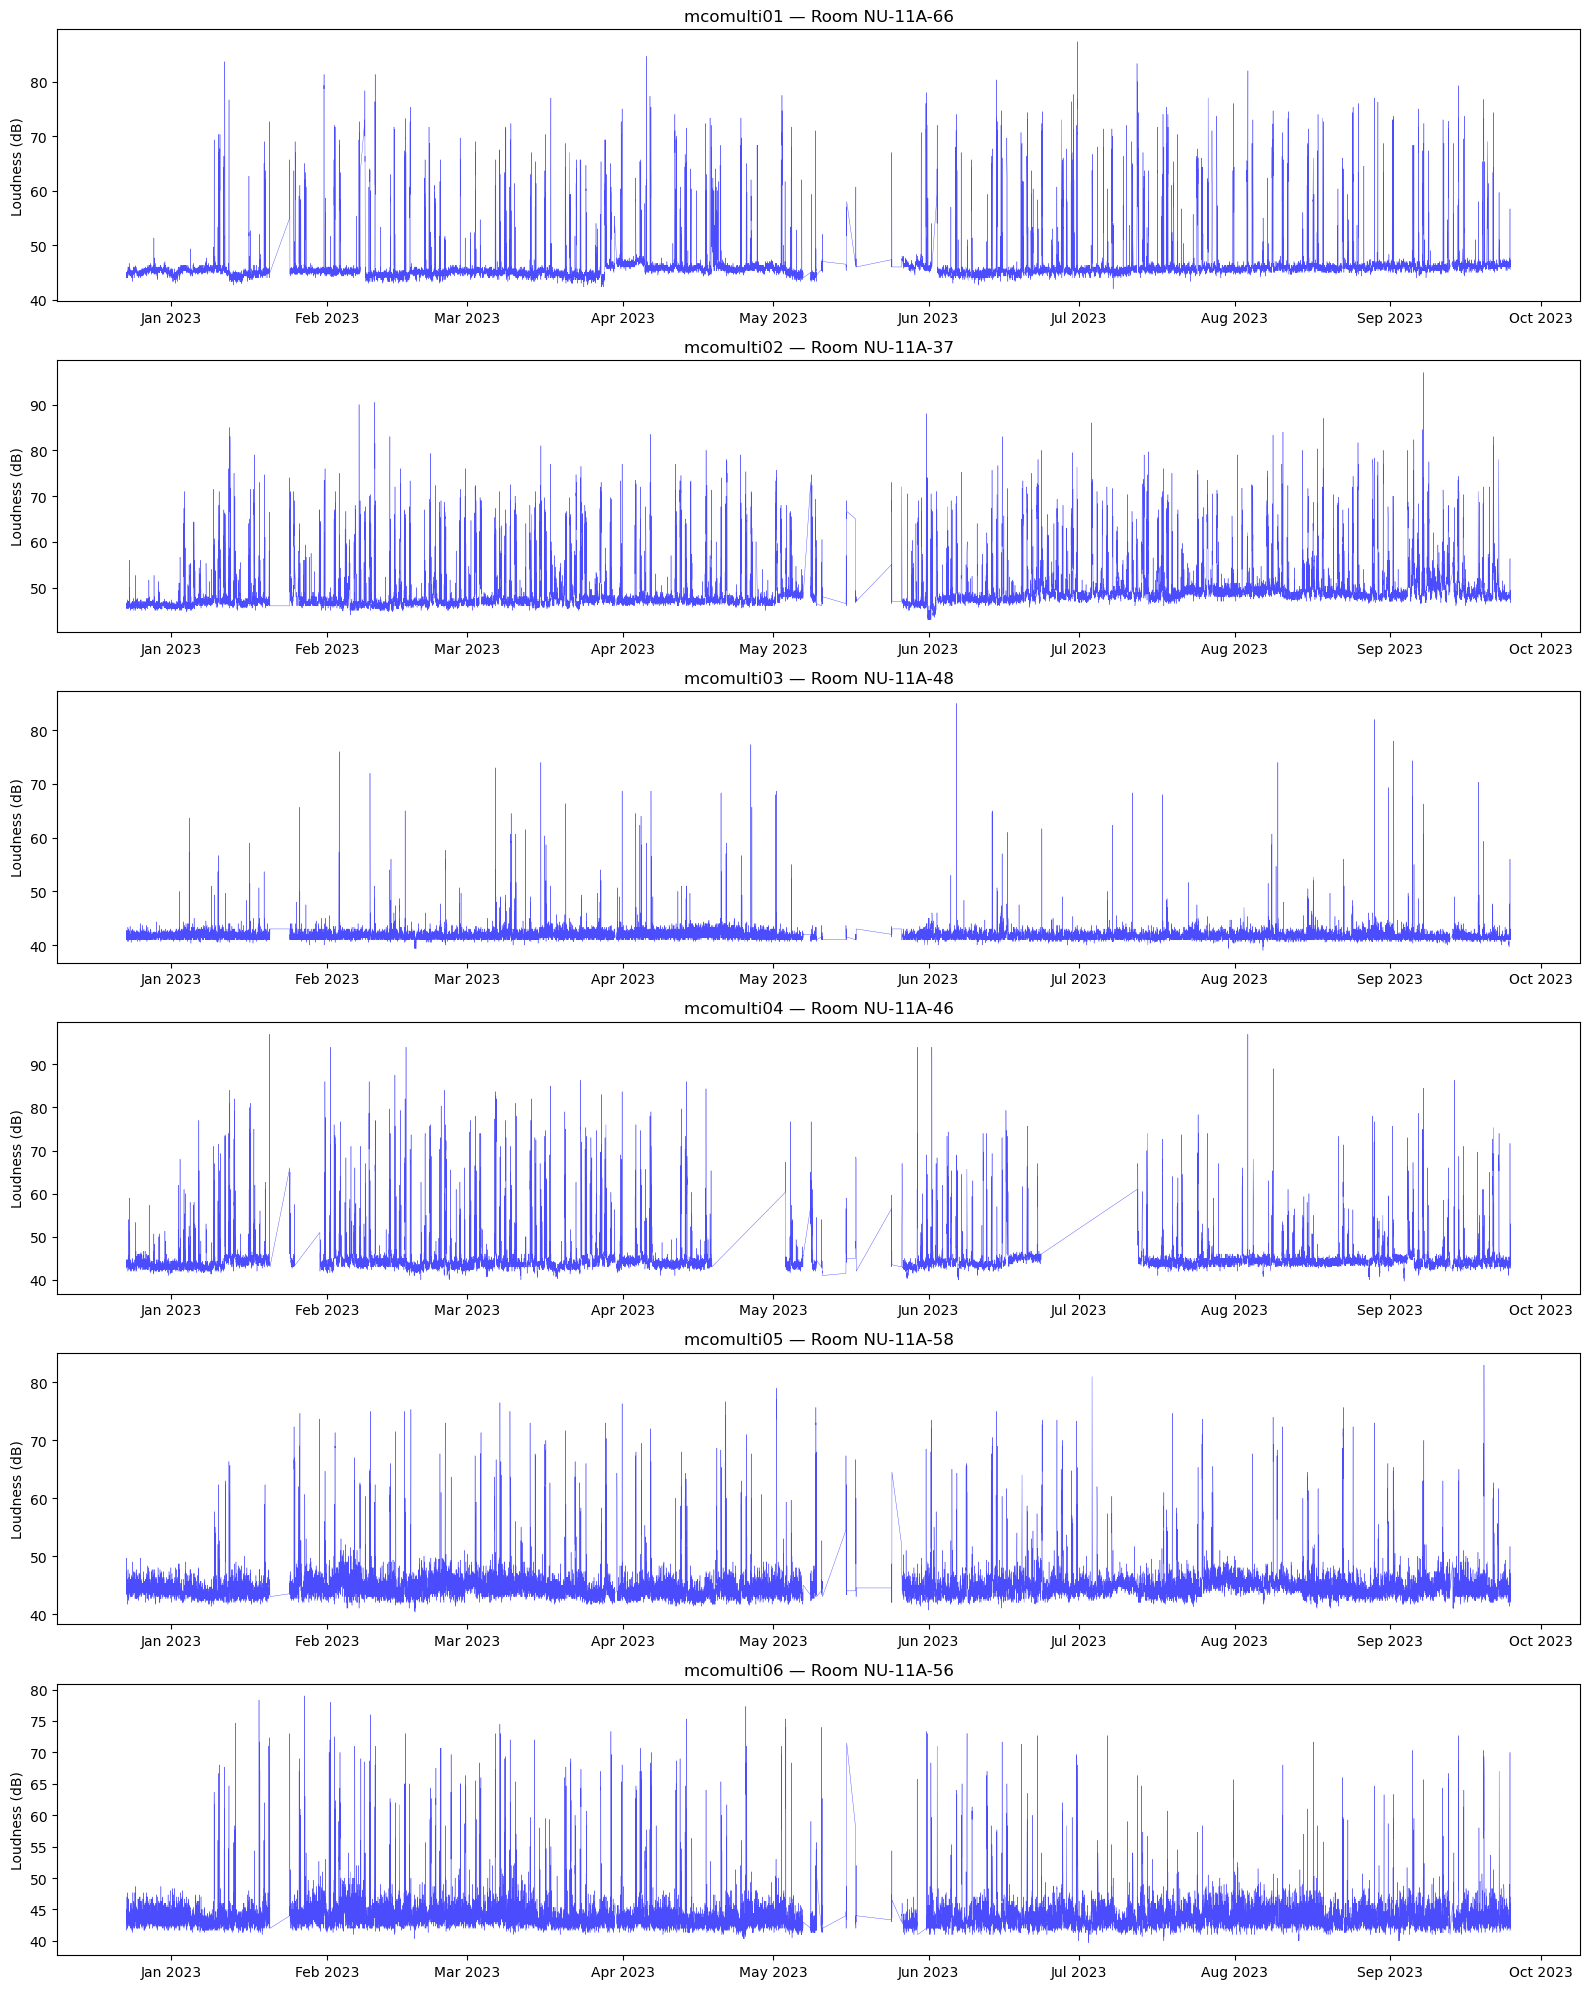

In [6]:
mco_rooms = {
    "mcomulti01": "NU-11A-66",
    "mcomulti02": "NU-11A-37",
    "mcomulti03": "NU-11A-48",
    "mcomulti04": "NU-11A-46",
    "mcomulti05": "NU-11A-58",
    "mcomulti06": "NU-11A-56"
}

dfs_loudness = []
for sensor, room in mco_rooms.items():
    query_loudness_over_time = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?val ?timestamp
WHERE {{
    nu:Loudness_{sensor}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df = execute_query(query_loudness_over_time)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["val"] = df["val"].astype(float)
    df["sensor"] = sensor
    df["room"] = room
    dfs_loudness.append(df)

df_loudness = pd.concat(dfs_loudness, ignore_index=True)

fig, axes = plt.subplots(6, 1, figsize=(16, 20))
for idx, (sensor, room) in enumerate(mco_rooms.items()):
    df_s = df_loudness[df_loudness["sensor"] == sensor]
    axes[idx].plot(df_s["timestamp"], df_s["val"],
                   linewidth=0.3, alpha=0.7, color="blue")
    axes[idx].set_title(f"{sensor} — Room {room}")
    axes[idx].set_ylabel("Loudness (dB)")
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

### Average loudness per hour on weekends vs Weekdays

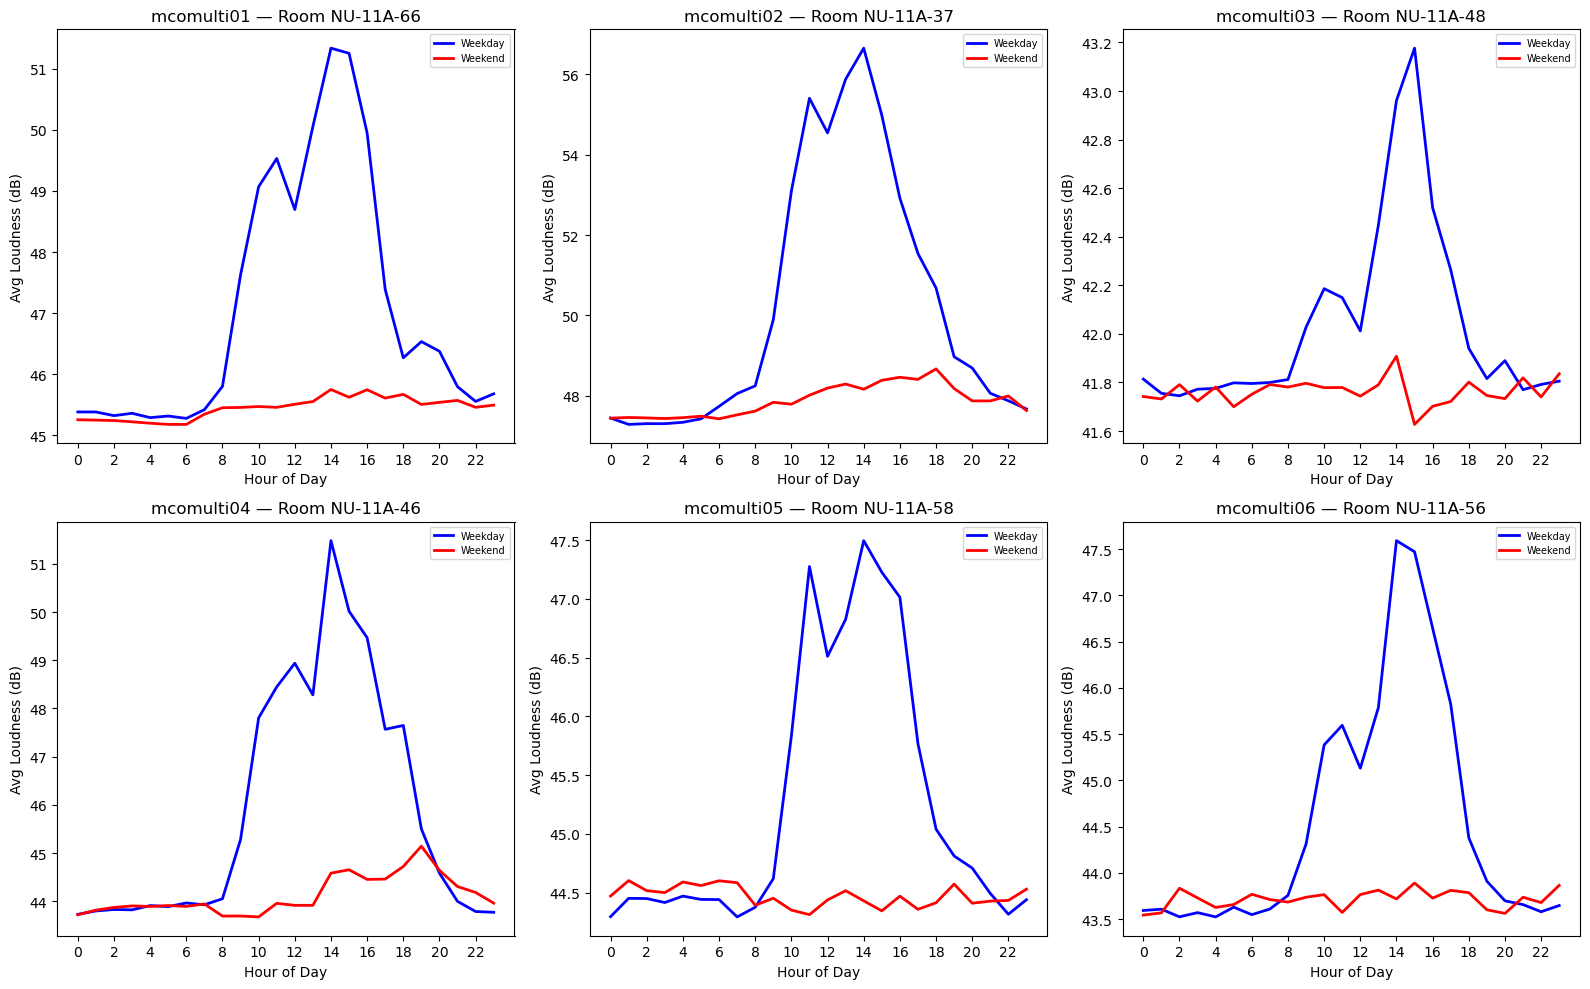

In [7]:
df_loudness["hour"] = df_loudness["timestamp"].dt.hour
df_loudness["dayofweek"] = df_loudness["timestamp"].dt.dayofweek
df_loudness["is_weekend"] = df_loudness["dayofweek"] >= 5

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (sensor, room) in enumerate(mco_rooms.items()):
    df_s = df_loudness[df_loudness["sensor"] == sensor]
    
    hourly_weekday = df_s[~df_s["is_weekend"]].groupby("hour")["val"].mean()
    hourly_weekend = df_s[df_s["is_weekend"]].groupby("hour")["val"].mean()
    
    axes[idx].plot(hourly_weekday.index, hourly_weekday.values, 
                   color="blue", label="Weekday", linewidth=2)
    axes[idx].plot(hourly_weekend.index, hourly_weekend.values,
                   color="red", label="Weekend", linewidth=2)
    axes[idx].set_title(f"{sensor} — Room {room}")
    axes[idx].set_xlabel("Hour of Day")
    axes[idx].set_ylabel("Avg Loudness (dB)")
    axes[idx].legend(fontsize=7)
    axes[idx].set_xticks(range(0, 24, 2))
    
plt.tight_layout()
plt.show()

### Distribution of all loudness values across all MCO sensors

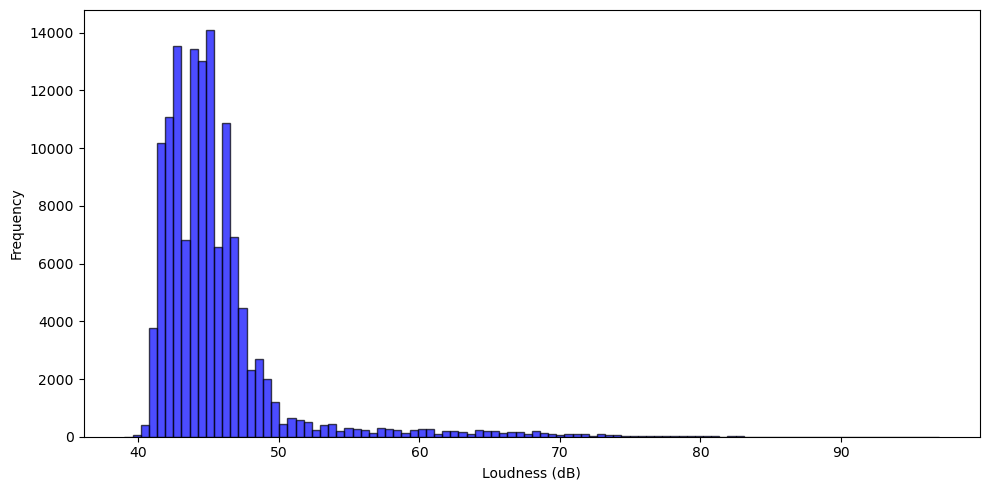

Loudness statistics:
count    132698.000000
mean         45.432380
std           4.679278
min          39.000000
25%          43.000000
50%          44.670000
75%          46.330000
max          97.000000
Name: val, dtype: float64

Percentiles:
  50th percentile: 44.67 dB
  75th percentile: 46.33 dB
  80th percentile: 46.67 dB
  85th percentile: 47.33 dB
  90th percentile: 48.67 dB
  95th percentile: 53.33 dB


In [219]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_loudness["val"], bins=100, color="blue", 
        edgecolor="black", alpha=0.7)
ax.set_xlabel("Loudness (dB)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Loudness statistics:")
print(df_loudness["val"].describe())
print(f"\nPercentiles:")
for p in [50, 75, 80, 85, 90, 95]:
    print(f"  {p}th percentile: {df_loudness['val'].quantile(p/100):.2f} dB")

### Loudness vs CO2 (rooms with windows)

mcomulti02 (NU-11A-37): Loudness vs CO2 correlation = 0.600


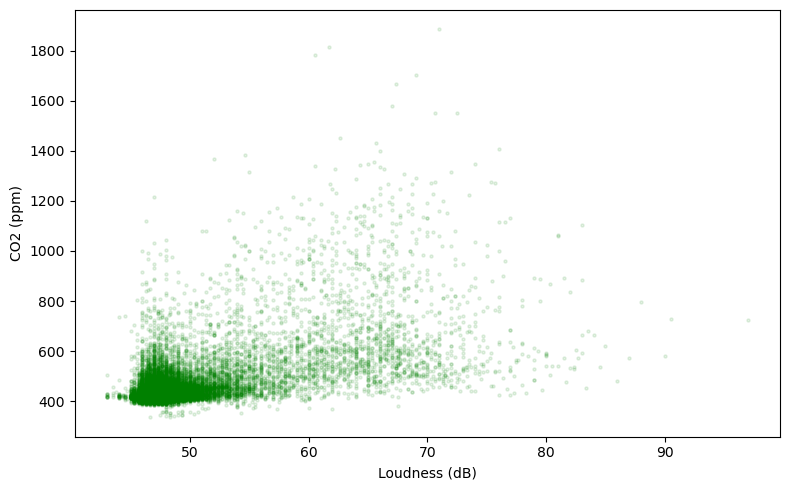

In [220]:
rooms_with_windows = {
    "mcomulti02": "NU-11A-37" 
}
rooms_no_windows = {
    "mcomulti01": "NU-11A-66",
    "mcomulti03": "NU-11A-48",
    "mcomulti04": "NU-11A-46",
    "mcomulti05": "NU-11A-58",
    "mcomulti06": "NU-11A-56"
}

query_co2 = """
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?val ?timestamp
WHERE {
    nu:eCO2_mcomulti02_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}
ORDER BY ?timestamp
"""
df_co2 = execute_query(query_co2)
df_co2["timestamp"] = pd.to_datetime(df_co2["timestamp"])
df_co2["val"] = df_co2["val"].astype(float)
df_co2 = df_co2.rename(columns={"val": "co2"})

df_loud02 = df_loudness[df_loudness["sensor"] == "mcomulti02"][["timestamp", "val"]].rename(columns={"val": "loudness"})
df_corr_windows = df_loud02.merge(df_co2[["timestamp", "co2"]], on="timestamp", how="inner")

corr_windows = df_corr_windows["loudness"].corr(df_corr_windows["co2"])
print(f"mcomulti02 (NU-11A-37): Loudness vs CO2 correlation = {corr_windows:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_corr_windows["loudness"], df_corr_windows["co2"],
           alpha=0.1, s=5, color="green")
ax.set_xlabel("Loudness (dB)")
ax.set_ylabel("CO2 (ppm)")
plt.tight_layout()
plt.show()

### Loudness vs Illuminance (rooms without windows)

In [238]:
for sensor, room in rooms_no_windows.items():
    query_illum = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:Illuminance_{sensor}_floor11 saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
    df_illum = execute_query(query_illum)
    df_illum["timestamp"] = pd.to_datetime(df_illum["timestamp"])
    df_illum["val"] = df_illum["val"].astype(float)
    df_illum = df_illum.rename(columns={"val": "illuminance"})
    df_loud_s = df_loudness[df_loudness["sensor"] == sensor][["timestamp", "val"]].rename(columns={"val": "loudness"})
    df_corr = df_loud_s.merge(df_illum[["timestamp", "illuminance"]], on="timestamp", how="inner")
    corr = df_corr["loudness"].corr(df_corr["illuminance"])
    print(f"{sensor} ({room}): Loudness vs Illuminance = {corr:.3f}")

mcomulti01 (NU-11A-66): Loudness vs Illuminance = 0.334
mcomulti03 (NU-11A-48): Loudness vs Illuminance = 0.246
mcomulti04 (NU-11A-46): Loudness vs Illuminance = 0.410
mcomulti05 (NU-11A-58): Loudness vs Illuminance = 0.280
mcomulti06 (NU-11A-56): Loudness vs Illuminance = 0.237


### MCO Threshold Definition

In [222]:
THRESHOLD_MCO = 48
df_loudness["occupied"] = (df_loudness["val"] > THRESHOLD_MCO).astype(int)

print(f"\nMCO Proxy (threshold = {THRESHOLD_MCO} dB)")
print(f"Occupied readings:   {df_loudness['occupied'].sum()}")
print(f"Unoccupied readings: {(df_loudness['occupied'] == 0).sum()}")
print(f"Occupancy rate:      {df_loudness['occupied'].mean():.2%}")


MCO Proxy (threshold = 48 dB)
Occupied readings:   15275
Unoccupied readings: 117423
Occupancy rate:      11.51%


### Temporal validation accrding to MCO Threshold

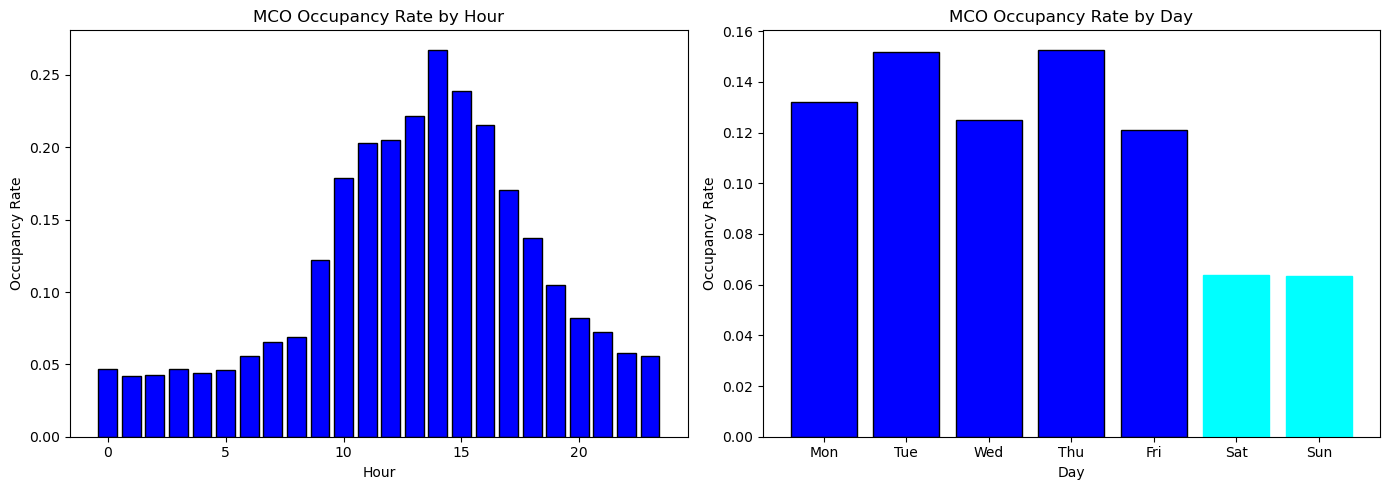

In [223]:
df_loudness["hour"] = df_loudness["timestamp"].dt.hour
df_loudness["dayofweek"] = df_loudness["timestamp"].dt.dayofweek
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hourly = df_loudness.groupby("hour")["occupied"].mean()
axes[0].bar(hourly.index, hourly.values, color="blue", edgecolor="black")
axes[0].set_title("MCO Occupancy Rate by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Occupancy Rate")

daily = df_loudness.groupby("dayofweek")["occupied"].mean()
bars = axes[1].bar(day_names, daily.values, color="blue", edgecolor="black")
bars[5].set_color("aqua")
bars[6].set_color("aqua")
axes[1].set_title("MCO Occupancy Rate by Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Occupancy Rate")

plt.tight_layout()
plt.show()

In [224]:
df_loudness.to_pickle("df_mco_occupancy.pkl")
print("Saved df_mco_occupancy.pkl")

Saved df_mco_occupancy.pkl


## Part 2 - Thingy Proxy

In [225]:
thingy_rooms_windows = {
    "NU-10A-01": ["thingy015_floor10", "thingy016_floor10"],
    "NU-10A-13": ["thingy012_floor10", "thingy017_floor10"],
    
    "NU-11A-29": ["thingy035_floor11", "thingy037_floor11", "thingy038_floor11"],
    "NU-11A-33": ["thingy031_floor11", "thingy032_floor11"],
    "NU-11A-37": ["thingy033_floor11", "thingy034_floor11"],
    "NU-11A-60": ["thingy006_floor11", "thingy008_floor11"],
    "NU-11A-65": ["thingy001_floor11", "thingy021_floor11", "thingy022_floor11",
                  "thingy023_floor11", "thingy024_floor11", "thingy025_floor11",
                  "thingy026_floor11", "thingy027_floor11", "thingy028_floor11"],
    
    "NU-12A-48": ["thingy047_floor12"],
    "NU-12A-55": ["thingy065_floor12", "thingy068_floor12"],
    "NU-12A-57": ["thingy061_floor12", "thingy062_floor12"],
    "NU-12A-59": ["thingy063_floor12", "thingy064_floor12"],
    "NU-12A-60": ["thingy045_floor12", "thingy046_floor12"],
}

thingy_rooms_no_windows = {
    "NU-11A-46": ["thingy055_floor11", "thingy056_floor11"],
    "NU-11A-48": ["thingy053_floor11", "thingy054_floor11"],
    "NU-11A-56": ["thingy051_floor11", "thingy052_floor11"],
    "NU-11A-58": ["thingy002_floor11", "thingy004_floor11"],
    "NU-11A-66": ["thingy003_floor11", "thingy058_floor11"],
    
    "NU-12A-56": ["thingy041_floor12", "thingy042_floor12"],
    "NU-12A-58": ["thingy043_floor12", "thingy044_floor12"],
}

### Timestamps kept after keeping median sensor sound per room

In [226]:
dfs_sound = []

all_thingy_rooms = {**thingy_rooms_windows, **thingy_rooms_no_windows}

for room, sensors in all_thingy_rooms.items():
    room_dfs = []
    for sensor in sensors:
        query_sound = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>

SELECT ?val ?timestamp
WHERE {{
    nu:Sound_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
        df = execute_query(query_sound)
        if len(df) > 0:
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["val"] = df["val"].astype(float)
            df["sensor"] = sensor
            room_dfs.append(df)

    if room_dfs:
        df_room = pd.concat(room_dfs)

        df_median = df_room.groupby("timestamp")["val"].median().reset_index()
        df_median["room"] = room
        dfs_sound.append(df_median)
        print(f"{room}: {len(df_median)} timestamps")

df_sound = pd.concat(dfs_sound, ignore_index=True)

NU-10A-01: 29803 timestamps
NU-10A-13: 10248 timestamps
NU-11A-29: 29777 timestamps
NU-11A-33: 29742 timestamps
NU-11A-37: 28741 timestamps
NU-11A-60: 28554 timestamps
NU-11A-65: 25043 timestamps
NU-12A-48: 12813 timestamps
NU-12A-55: 28536 timestamps
NU-12A-57: 28574 timestamps
NU-12A-59: 28573 timestamps
NU-12A-60: 28159 timestamps
NU-11A-46: 25233 timestamps
NU-11A-48: 24560 timestamps
NU-11A-56: 13222 timestamps
NU-11A-58: 28581 timestamps
NU-11A-66: 13761 timestamps
NU-12A-56: 23866 timestamps
NU-12A-58: 19267 timestamps


### Sound over time per room

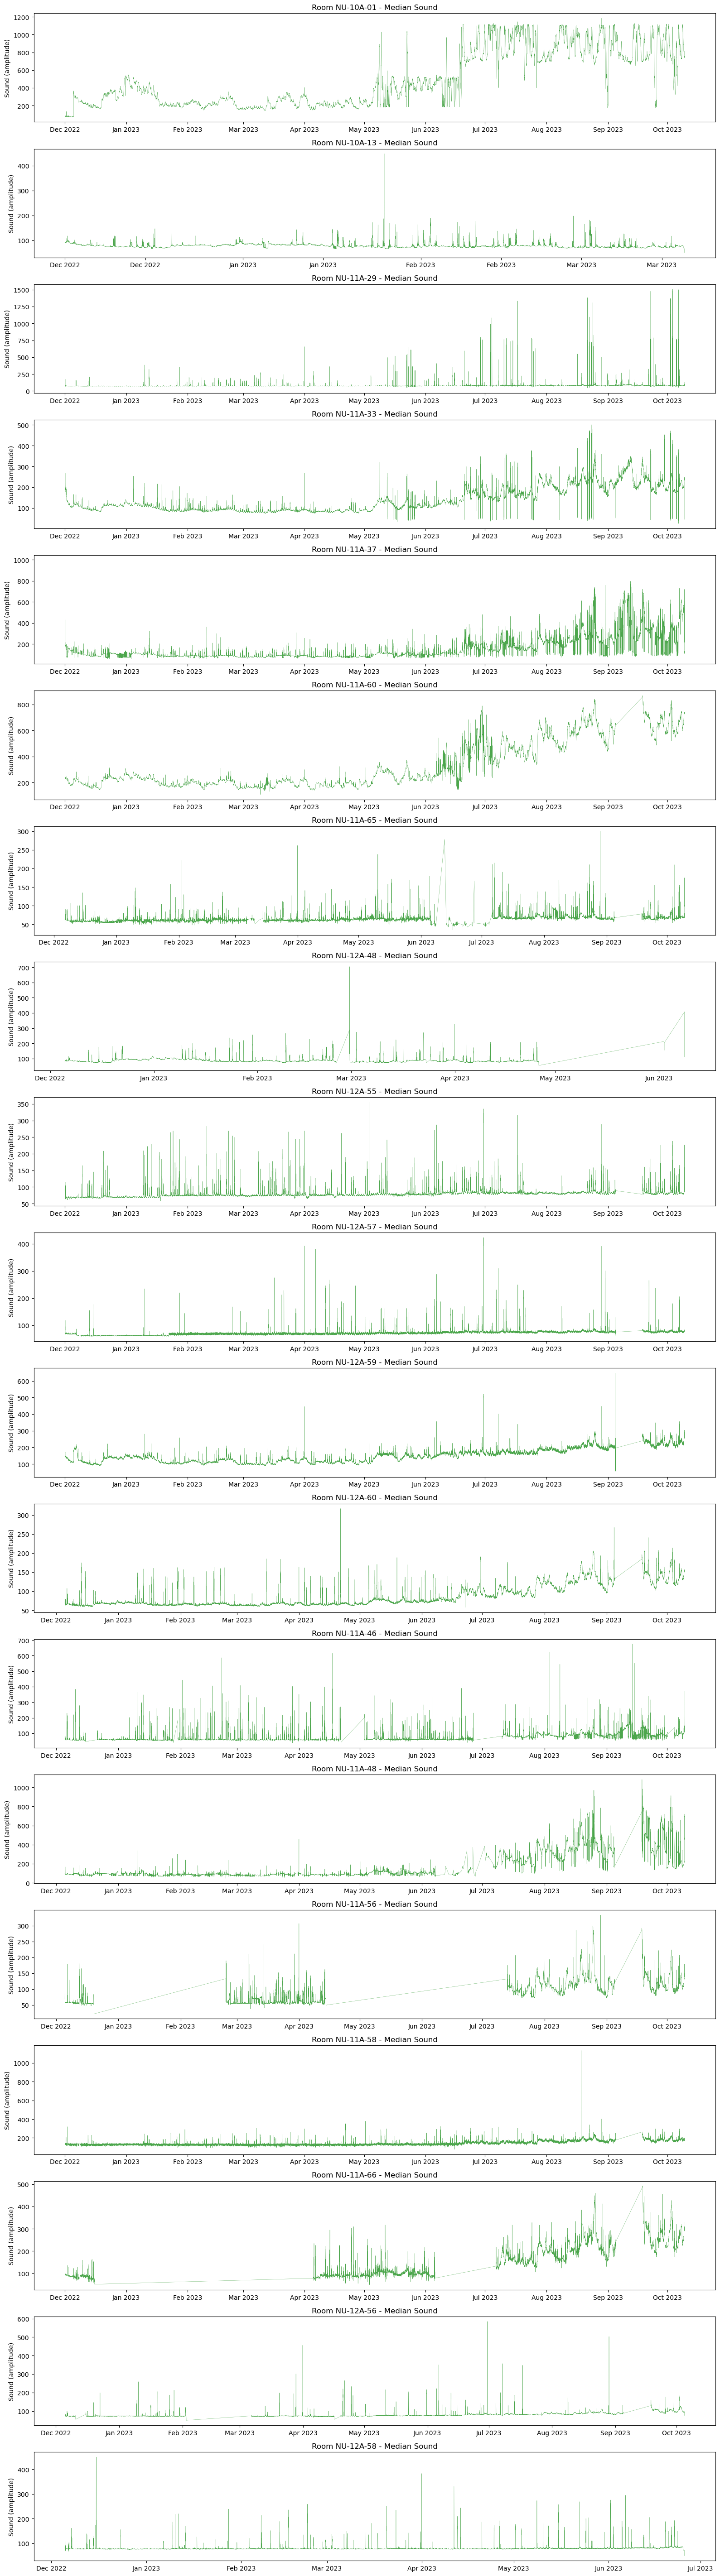

In [227]:
rooms_to_plot = list(all_thingy_rooms.keys())
fig, axes = plt.subplots(len(rooms_to_plot), 1, figsize=(16, 3 * len(rooms_to_plot)))
for idx, room in enumerate(rooms_to_plot):
    df_r = df_sound[df_sound["room"] == room]
    axes[idx].plot(df_r["timestamp"], df_r["val"],
                   linewidth=0.3, alpha=0.7, color="green")
    axes[idx].set_title(f"Room {room} - Median Sound")
    axes[idx].set_ylabel("Sound (amplitude)")
    axes[idx].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

### Average loudness per hour on weekends vs Weekdays

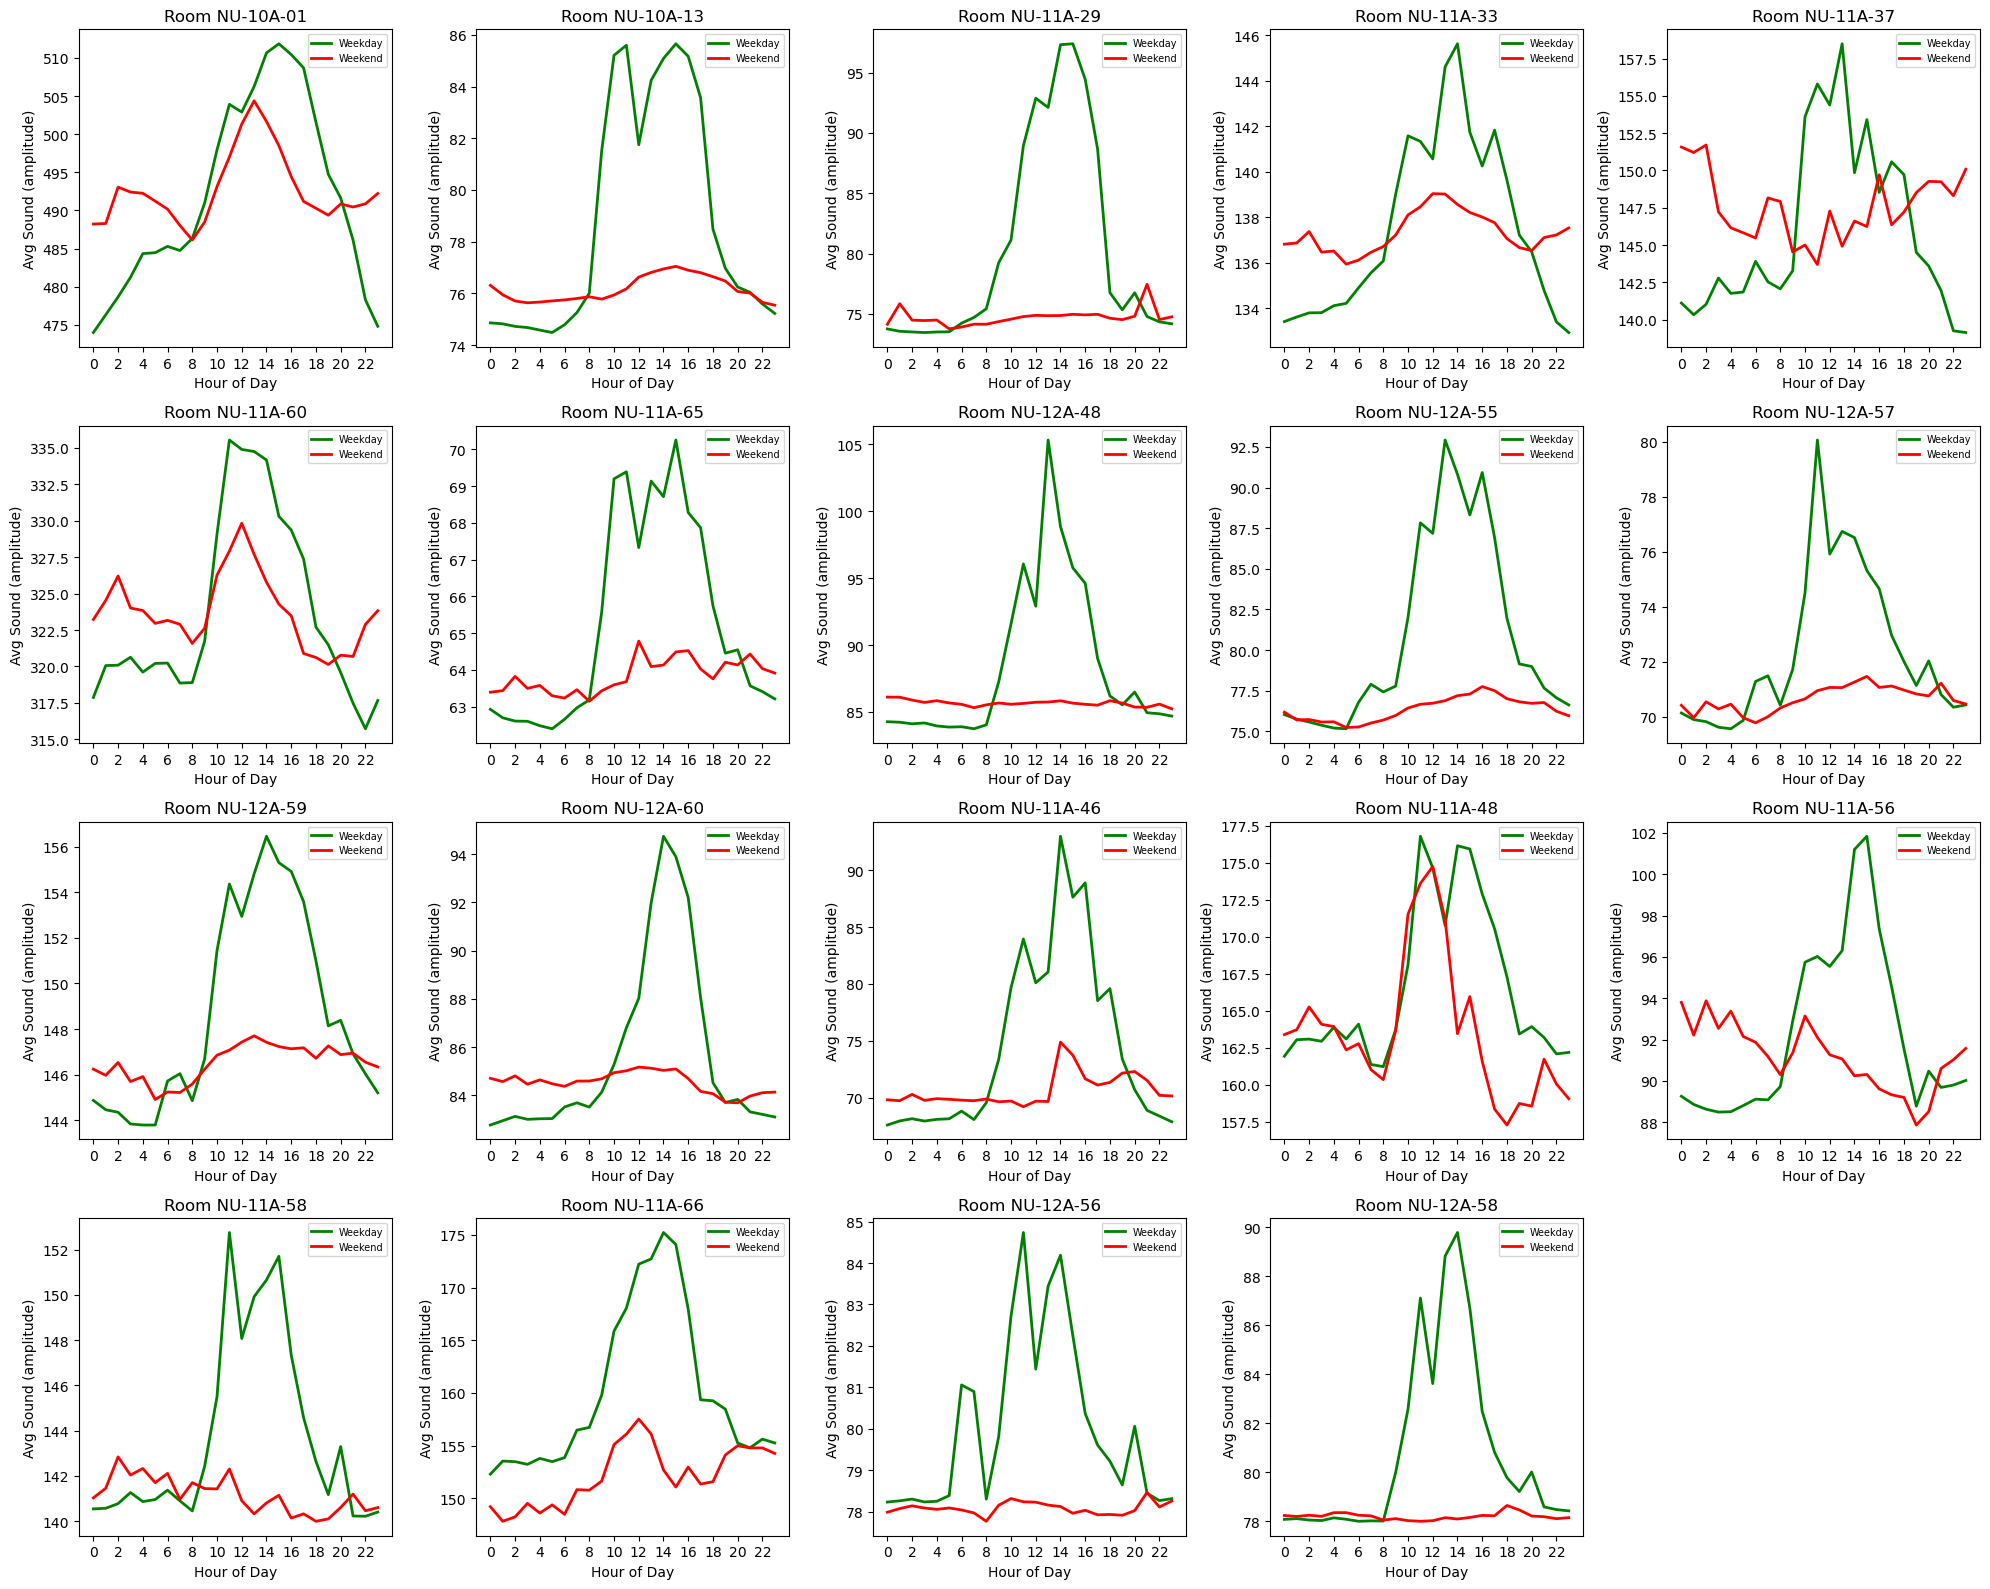

In [228]:
df_sound["hour"] = df_sound["timestamp"].dt.hour
df_sound["dayofweek"] = df_sound["timestamp"].dt.dayofweek
df_sound["is_weekend"] = df_sound["dayofweek"] >= 5

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, room in enumerate(all_thingy_rooms.keys()):
    df_r = df_sound[df_sound["room"] == room]
    
    hourly_weekday = df_r[~df_r["is_weekend"]].groupby("hour")["val"].mean()
    hourly_weekend = df_r[df_r["is_weekend"]].groupby("hour")["val"].mean()
    
    axes[idx].plot(hourly_weekday.index, hourly_weekday.values,
                   color="green", label="Weekday", linewidth=2)
    axes[idx].plot(hourly_weekend.index, hourly_weekend.values,
                   color="red", label="Weekend", linewidth=2)
    axes[idx].set_title(f"Room {room}")
    axes[idx].set_xlabel("Hour of Day")
    axes[idx].set_ylabel("Avg Sound (amplitude)")
    axes[idx].legend(fontsize=7)
    axes[idx].set_xticks(range(0, 24, 2))

# Hide the one extra subplot because 4x5=20 but there exist only 19 rooms
for idx in range(len(all_thingy_rooms), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Distribution of all sound values across all Thingy sensors

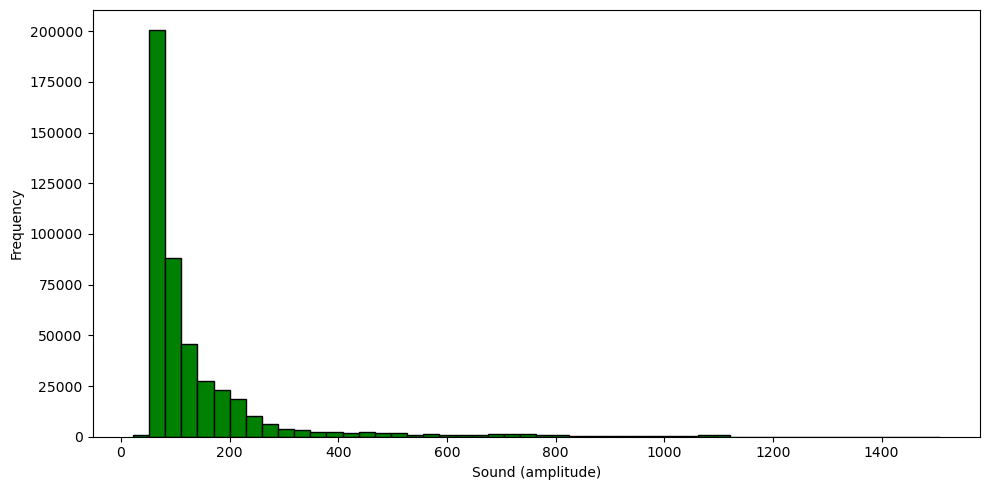


Thingy sound statistics:
count    457053.000000
mean        144.115138
std         151.729882
min          22.000000
25%          73.295000
50%          85.955000
75%         150.110000
max        1507.000000
Name: val, dtype: float64


In [229]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_sound["val"], bins=50, color="green", edgecolor="black")
ax.set_xlabel("Sound (amplitude)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"\nThingy sound statistics:")
print(df_sound["val"].describe())

### Room exclusion after physical inspection

In [231]:
excluded_rooms = [
    'NU-10A-01',
    'NU-11A-60',
    'NU-11A-66',
    'NU-11A-33',
    'NU-11A-37',
    'NU-11A-48',
    'NU-11A-58',
    'NU-12A-59'
]
df_sound_clean = df_sound[~df_sound['room'].isin(excluded_rooms)].copy()

thingy_rooms_windows_clean = {
    room: sensors 
    for room, sensors in thingy_rooms_windows.items() 
    if room not in excluded_rooms
}

thingy_rooms_no_windows_clean = {
    room: sensors 
    for room, sensors in thingy_rooms_no_windows.items() 
    if room not in excluded_rooms
}

### Sound-eCO2 correlation in rooms with windows

In [242]:
for room, sensors in thingy_rooms_windows_clean.items():
    dfs_eco2 = []
    for sensor in sensors:
        query_sound_eCO2 = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:eCO2_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
        df_eco2 = execute_query(query_sound_eCO2)
        if len(df_eco2) > 0:
            df_eco2["timestamp"] = pd.to_datetime(df_eco2["timestamp"])
            df_eco2["val"] = df_eco2["val"].astype(float)
            dfs_eco2.append(df_eco2[["timestamp", "val"]])
    
    if dfs_eco2:
        # Median across all sensors per timestamp
        df_eco2_all = pd.concat(dfs_eco2)
        df_eco2_median = df_eco2_all.groupby("timestamp")["val"].median().reset_index()
        df_eco2_median = df_eco2_median.rename(columns={"val": "eco2"})
        
        df_room_sound = df_sound_clean[df_sound_clean["room"] == room][["timestamp", "val"]].rename(columns={"val": "sound"})
        df_corr = df_room_sound.merge(df_eco2_median, on="timestamp", how="inner")
        if len(df_corr) > 0:
            corr = df_corr["sound"].corr(df_corr["eco2"])
            print(f"{room}: Sound vs eCO2 correlation = {corr:.3f}")

NU-10A-13: Sound vs eCO2 correlation = -0.081
NU-11A-29: Sound vs eCO2 correlation = 0.030
NU-11A-65: Sound vs eCO2 correlation = 0.118
NU-12A-48: Sound vs eCO2 correlation = 0.282
NU-12A-55: Sound vs eCO2 correlation = 0.051
NU-12A-57: Sound vs eCO2 correlation = 0.151
NU-12A-60: Sound vs eCO2 correlation = 0.146


### Sound-Color_c correlation in rooms without windows

In [243]:
for room, sensors in thingy_rooms_no_windows_clean.items():
    dfs_colorc = []
    for sensor in sensors:
        query_sound_color_c = f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:ColorC_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""
        df_colorc = execute_query(query_sound_color_c)
        if len(df_colorc) > 0:
            df_colorc["timestamp"] = pd.to_datetime(df_colorc["timestamp"])
            df_colorc["val"] = df_colorc["val"].astype(float)
            dfs_colorc.append(df_colorc[["timestamp", "val"]])
    
    if dfs_colorc:
        # Median across all sensors per timestamp
        df_colorc_all = pd.concat(dfs_colorc)
        df_colorc_median = df_colorc_all.groupby("timestamp")["val"].median().reset_index()
        df_colorc_median = df_colorc_median.rename(columns={"val": "color_c"})
        
        df_room_sound = df_sound_clean[df_sound_clean["room"] == room][["timestamp", "val"]].rename(columns={"val": "sound"})
        df_corr = df_room_sound.merge(df_colorc_median, on="timestamp", how="inner")
        if len(df_corr) > 0:
            corr = df_corr["sound"].corr(df_corr["color_c"])
            print(f"{room}: Sound vs color_c correlation = {corr:.3f}")

NU-11A-46: Sound vs color_c correlation = 0.213
NU-11A-56: Sound vs color_c correlation = 0.037
NU-12A-56: Sound vs color_c correlation = 0.173
NU-12A-58: Sound vs color_c correlation = 0.289


### Thingy Threshold Definition

In [234]:
THRESHOLD_THINGY = 90
df_sound_clean["occupied"] = (df_sound_clean["val"] > THRESHOLD_THINGY).astype(int)
print(f"\nThingy Proxy (threshold = {THRESHOLD_THINGY})")
print(f"Occupied:    {df_sound_clean['occupied'].sum()}")
print(f"Unoccupied:  {(df_sound_clean['occupied'] == 0).sum()}")
print(f"Occupancy rate: {df_sound_clean['occupied'].mean():.2%}")


Thingy Proxy (threshold = 90)
Occupied:    31083
Unoccupied:  213655
Occupancy rate: 12.70%


### Temporal Validation according to Thingy Threshold

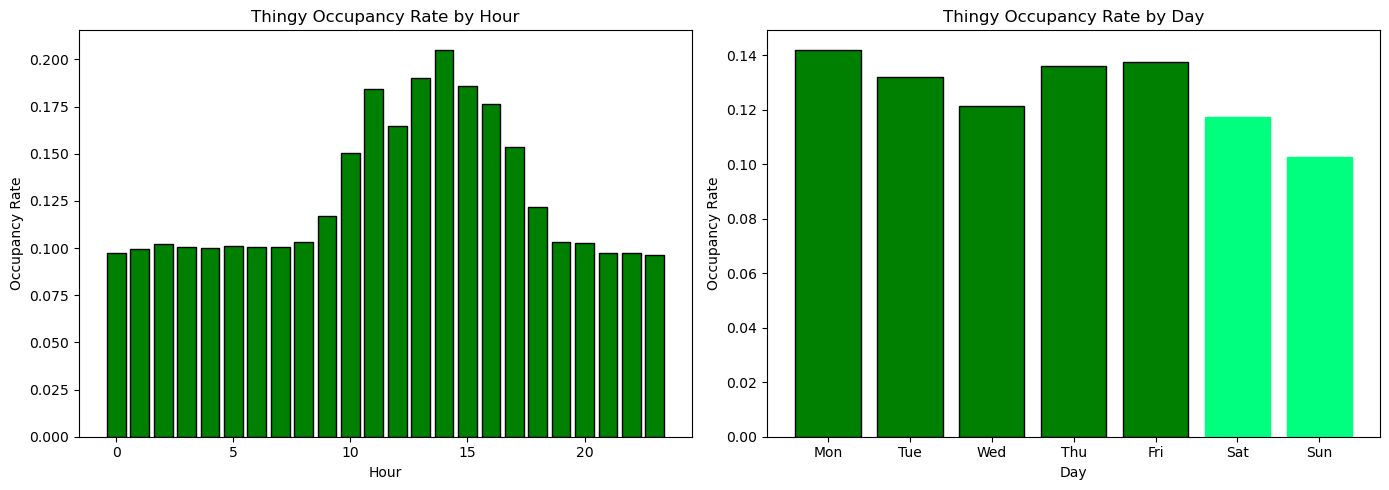

In [235]:
df_sound_clean["hour"] = df_sound_clean["timestamp"].dt.hour
df_sound_clean["dayofweek"] = df_sound_clean["timestamp"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df_sound_clean.groupby("hour")["occupied"].mean()
axes[0].bar(hourly.index, hourly.values, color="green", edgecolor="black")
axes[0].set_title("Thingy Occupancy Rate by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Occupancy Rate")

daily = df_sound_clean.groupby("dayofweek")["occupied"].mean()
bars = axes[1].bar(day_names, daily.values, color="green", edgecolor="black")
bars[5].set_color("springgreen")
bars[6].set_color("springgreen")
axes[1].set_title("Thingy Occupancy Rate by Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Occupancy Rate")

plt.tight_layout()
plt.show()

In [236]:
df_sound_clean.to_pickle("df_thingy_occupancy.pkl")
print("Saved df_thingy_occupancy.pkl")

Saved df_thingy_occupancy.pkl
